# Imports

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import glob
import math
import time
import subprocess
import os
from IPython.display import clear_output
from matplotlib import cm
CMAP = cm.summer


from analysis import *
from sim_funcs import *

# Processing the simulation data 

In [2]:
fname = "flux_rates_full_moon_250"
consolidate_sims(fname)
thetas, phis, flux = read_flux_file(fname)



(array([10., 10.,  9., 13., 17., 17., 23., 26., 38., 87.]),
 array([1044.99216031, 1430.41551983, 1815.83887936, 2201.26223888,
        2586.68559841, 2972.10895793, 3357.53231745, 3742.95567698,
        4128.3790365 , 4513.80239603, 4899.22575555]),
 <BarContainer object of 10 artists>)

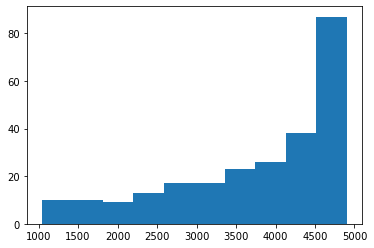

In [7]:
plt.hist(flux)

# Figures

In [21]:
x,y,z = fibonacci_sphere(samples=10000)
r,phi_fill,theta_fill = conv_cart_to_sph(x,y,z)
impact_fill = interp_impact_rates(np.degrees(phi_fill), np.degrees(theta_fill), fname)
theta_fill = theta_fill-np.pi
phi_fill=((phi_fill-0.5*np.pi)*-1.0)


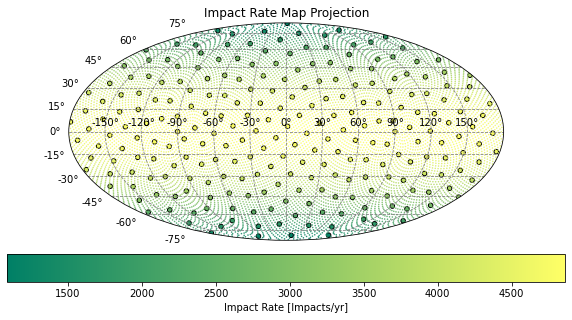

In [26]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection="mollweide")

theta_rad = np.radians(thetas-180)
phi_rad = np.radians((phis-90)*-1.0)
colors = CMAP((flux-np.min(flux))/(np.max(flux)-np.min(flux)))

plt.scatter(theta_rad, phi_rad, c=flux, cmap=CMAP, s=20,edgecolor="black")
plt.scatter(theta_fill,phi_fill, c=impact_fill, cmap=CMAP, s=0.25)
cbar = plt.colorbar(orientation="horizontal", pad=0.05)
cbar.set_label("Impact Rate [Impacts/yr]")

ax.grid(True, linestyle="--", color="gray")
plt.title("Impact Rate Map Projection")
plt.savefig("figures/impacts_full_moon_min_mass.pdf", bbox_inches="tight")

# Interpolation and measuring impacts near the proposed lunar bases

In [13]:


theta_base = np.radians([77.0, 0.0, 210.0, 220.0, 270.0, 260.0, 250.0, 356.6, 0.0, 45.0, 40.0, 42.0, 85.0])
phi_base = np.radians(np.array([-87.4, -89.8, -89.5, -89.2, -88.5, -88.7, -88.2, -87.6, -85.8, -84.9, -86.7, -86.5, -84.4])*-1+90)
name_base = ["Faustini Rim A", "Peak Near Shackleton", "Connecting Ridge", "Connecting Ridge Extension", "de Gerlache Rim 1","de Gerlache Rim 2", "de Gerlache-Kocher Massif", "Haworth", "Malapert Massif", "Leibnitz Beta Plateau", "Nobile Rim 1", "Nobile Rim 2", "Amundsen Rim"]
impact_base = []
for x in range(len(theta_base)):
    rate = interp_impact_rates(phi_base[x], theta_base[x], fname)
    impact_base.append(float(rate))
ind = np.argmin(impact_base)
safest = name_base[ind]
print("The safest proposed base location is at " +safest)
print("The impact rates at the other bases:", list(impact_base))


The safest proposed base location is at Peak Near Shackleton
The impact rates at the other bases: [1534.2999944335972, 1502.192837193791, 1590.9091200367948, 1595.3799315159945, 1617.8501923146875, 1613.3080286506993, 1608.919936033659, 1657.8026110473738, 1502.9673156009285, 1521.5163453655307, 1519.1094553719108, 1519.9708992449769, 1538.2259945669614]
